Mounted at /content/drive
['/', 'column_2C.dat', 'column_3C.dat', 'column_2C_weka.arff', 'column_3C_weka.arff']
using: /content/vertebral/column_2C_weka.arff
y
1    210
0    100
Name: count, dtype: int64
train: 210  test: 100
k* = 4   test error = 0.0600


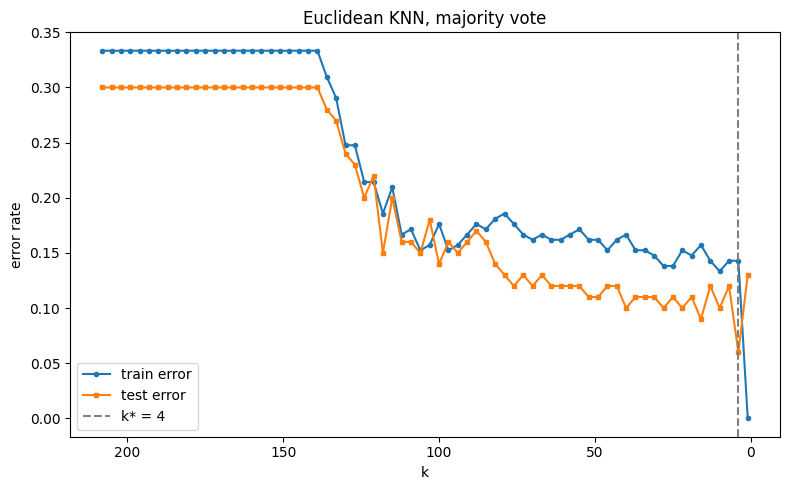


--- metrics at k* ---
Confusion matrix [[TP FN],[FP TN]] =
 [[69  1]
 [ 5 25]]
TPR=0.986  TNR=0.833  precision=0.932  F1=0.958


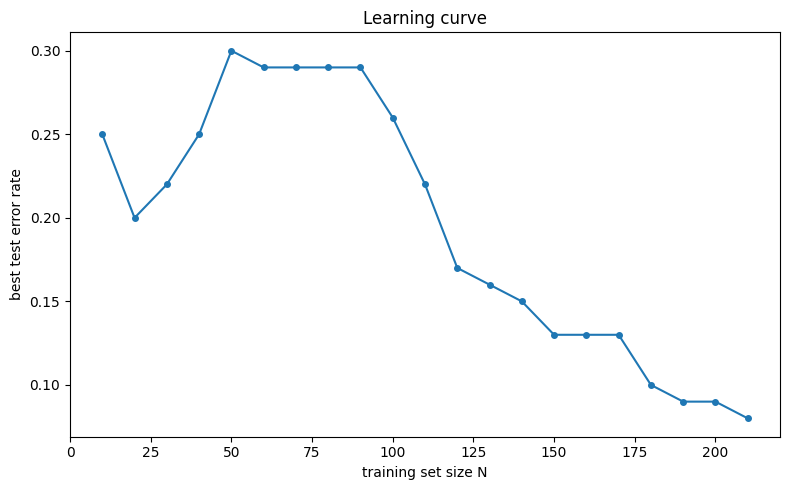

(d)iB best log10(p) = 0.7  (p=5.01)  err=0.1100

(d) summary of test errors:
                metric  best_k  test_error
             Chebyshev      16        0.08
             Euclidean       6        0.08
Minkowski log10(p)=0.7       1        0.11
       Manhattan (p=1)       1        0.11
           Mahalanobis       1        0.15

(e) distance-weighted voting, best test errors:
   metric  best_k  test_error
Euclidean       6        0.10
Manhattan      26        0.10
Chebyshev      16        0.11

(f) lowest training error rate = 0.0000  (achieved at k = 1)


In [ ]:
"""
EE 559 - Homework 1, Problem 7
Vertebral Column Data Set - KNN classification

Binary task:  NO (Normal) = 0,  AB (Abnormal) = 1   (positive class = AB = 1)

Changed: uses column_2C_weka.arff (higher precision) instead of column_2C.dat,
per instructor's note.
"""

# %% ---------------------------------------------------------------- imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff                          # <-- NEW: for .arff loading
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# --- Colab: mount Drive, unzip, locate .arff file ---
from google.colab import drive
drive.mount('/content/drive')

import zipfile, glob
zip_path = '/content/drive/MyDrive/USC_Summer26/EE559/Data/vertebral_column_data.zip'
with zipfile.ZipFile(zip_path) as z:
    z.extractall('/content/vertebral')
    print(z.namelist())

# ---- CHANGED: .arff instead of .dat ----
DATA_PATH = glob.glob('/content/vertebral/**/column_2C_weka.arff', recursive=True)[0]
print('using:', DATA_PATH)


# %% ----------------------------------------------------- (a) load the data
def load_data(path=DATA_PATH):
    """Read column_2C_weka.arff (higher precision than .dat)."""
    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)
    # scipy arff returns bytes for nominal attributes -> decode
    for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
    # The class column is the last one (named 'class' in the Weka arff)
    class_col = meta.names()[-1]            # typically 'class'
    df['y'] = (df[class_col].str.upper().str[:2] == 'AB').astype(int)
    df = df.drop(columns=[class_col])       # drop original string class column
    return df


df = load_data()
COLS = [c for c in df.columns if c != 'y']  # all feature columns (auto-detected)
print(df['y'].value_counts())               # expect 1->210, 0->100


# %% --------------------------------------- (b) i. scatterplots, coloured by class
def scatter_matrix_by_class(df):
    g = sns.pairplot(df, vars=COLS, hue="y", diag_kind="hist",
                     plot_kws={"s": 12, "alpha": 0.6}, height=1.4)
    g.figure.suptitle("Pairwise scatterplots (0 = Normal, 1 = Abnormal)", y=1.02)
    plt.show()


# %% --------------------------------------- (b) ii. boxplots, coloured by class
def boxplots_by_class(df):
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    long = df.melt(id_vars="y", value_vars=COLS,
                   var_name="feature", value_name="value")
    for ax, feat in zip(axes.ravel(), COLS):
        sns.boxplot(data=long[long.feature == feat], x="y", y="value",
                    hue="y", ax=ax, legend=False)
        ax.set_title(feat); ax.set_xlabel("class")
    fig.tight_layout(); plt.show()


# %% -------------------------------------------- (b) iii. train / test split
def make_split(df, n0=70, n1=140):
    """First n0 rows of class 0 and first n1 rows of class 1 -> train; rest -> test."""
    df0, df1 = df[df.y == 0], df[df.y == 1]
    train = pd.concat([df0.iloc[:n0], df1.iloc[:n1]])
    test  = pd.concat([df0.iloc[n0:], df1.iloc[n1:]])
    Xtr, ytr = train[COLS].to_numpy(), train["y"].to_numpy()
    Xte, yte = test[COLS].to_numpy(),  test["y"].to_numpy()
    return Xtr, ytr, Xte, yte


Xtr, ytr, Xte, yte = make_split(df)
print(f"train: {Xtr.shape[0]}  test: {Xte.shape[0]}")  # 210 / 100


# %% --------------------------------- helper: fit KNN and return error rates
def knn_errors(Xtr, ytr, Xte, yte, k, **kw):
    """Return (train_error, test_error) for a KNN with the given settings."""
    k = min(k, len(Xtr))
    clf = KNeighborsClassifier(n_neighbors=k, **kw).fit(Xtr, ytr)
    tr_err = np.mean(clf.predict(Xtr) != ytr)
    te_err = np.mean(clf.predict(Xte) != yte)
    return tr_err, te_err


# %% ---------------------- (c) ii. error vs k, Euclidean, majority vote
k_values = list(range(1, 209, 3))              # {1, 4, 7, ..., 208}
train_err, test_err = [], []
for k in k_values:
    tr, te = knn_errors(Xtr, ytr, Xte, yte, k, metric="euclidean", weights="uniform")
    train_err.append(tr); test_err.append(te)

k_star = k_values[int(np.argmin(test_err))]
print(f"k* = {k_star}   test error = {min(test_err):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_err, "o-", ms=3, label="train error")
plt.plot(k_values, test_err,  "s-", ms=3, label="test error")
plt.axvline(k_star, ls="--", c="grey", label=f"k* = {k_star}")
plt.gca().invert_xaxis()
plt.xlabel("k"); plt.ylabel("error rate"); plt.legend()
plt.title("Euclidean KNN, majority vote"); plt.tight_layout(); plt.show()


# %% --------------- (c) ii. confusion matrix & metrics at k* (positive = AB = 1)
def report_metrics(Xtr, ytr, Xte, yte, k, **kw):
    clf = KNeighborsClassifier(n_neighbors=k, **kw).fit(Xtr, ytr)
    yhat = clf.predict(Xte)
    cm = confusion_matrix(yte, yhat, labels=[1, 0])   # rows/cols ordered [pos, neg]
    tp, fn, fp, tn = cm.ravel()
    tpr  = tp / (tp + fn)
    tnr  = tn / (tn + fp)
    prec = tp / (tp + fp)
    f1   = 2 * prec * tpr / (prec + tpr)
    print("Confusion matrix [[TP FN],[FP TN]] =\n", np.array([[tp, fn], [fp, tn]]))
    print(f"TPR={tpr:.3f}  TNR={tnr:.3f}  precision={prec:.3f}  F1={f1:.3f}")
    return dict(TP=tp, FN=fn, FP=fp, TN=tn, TPR=tpr, TNR=tnr, precision=prec, F1=f1)

print("\n--- metrics at k* ---")
report_metrics(Xtr, ytr, Xte, yte, k_star, metric="euclidean", weights="uniform")


# %% --------------------------------------- (c) iii. learning curve
def best_test_error_for_N(df, N):
    """Build the size-N training subset, sweep k in {1,6,...}, return min test error."""
    n0 = N // 3
    n1 = N - n0
    df0, df1 = df[df.y == 0], df[df.y == 1]
    sub = pd.concat([df0.iloc[:n0], df1.iloc[:n1]])
    Xs, ys = sub[COLS].to_numpy(), sub["y"].to_numpy()
    ks = [k for k in range(1, N, 5) if k <= len(Xs)]
    errs = [knn_errors(Xs, ys, Xte, yte, k, metric="euclidean")[1] for k in ks]
    return min(errs)

N_values = list(range(10, 211, 10))
lc = [best_test_error_for_N(df, N) for N in N_values]

plt.figure(figsize=(8, 5))
plt.plot(N_values, lc, "o-", ms=4)
plt.xlabel("training set size N"); plt.ylabel("best test error rate")
plt.title("Learning curve"); plt.tight_layout(); plt.show()


# %% --------------------------------------- (d) other distance metrics
ks_d = list(range(1, 197, 5))

def best_k(Xtr, ytr, Xte, yte, ks, **kw):
    errs = [knn_errors(Xtr, ytr, Xte, yte, k, **kw)[1] for k in ks]
    j = int(np.argmin(errs))
    return ks[j], errs[j]

results = {}

# (d) i.A  Manhattan  (Minkowski p = 1)
k_manh, err_manh = best_k(Xtr, ytr, Xte, yte, ks_d, metric="minkowski", p=1)
results["Manhattan (p=1)"] = (k_manh, err_manh)

# (d) i.B  Minkowski with log10(p) in {0.1,...,1.0}, reuse k* from Manhattan
log10p = np.arange(0.1, 1.0001, 0.1)
mink_errs = [(lp, knn_errors(Xtr, ytr, Xte, yte, k_manh,
                             metric="minkowski", p=10**lp)[1]) for lp in log10p]
best_lp, best_lp_err = min(mink_errs, key=lambda t: t[1])
print(f"(d)iB best log10(p) = {best_lp:.1f}  (p={10**best_lp:.2f})  err={best_lp_err:.4f}")
results[f"Minkowski log10(p)={best_lp:.1f}"] = (k_manh, best_lp_err)

# (d) i.C  Chebyshev  (Minkowski p -> inf)
k_cheb, err_cheb = best_k(Xtr, ytr, Xte, yte, ks_d, metric="chebyshev")
results["Chebyshev"] = (k_cheb, err_cheb)

# (d) ii.  Mahalanobis (pseudoinverse handles singular covariance)
VI = np.linalg.pinv(np.cov(Xtr, rowvar=False))
k_mah, err_mah = best_k(Xtr, ytr, Xte, yte, ks_d,
                        metric="mahalanobis", metric_params={"VI": VI},
                        algorithm="brute")
results["Mahalanobis"] = (k_mah, err_mah)

# also Euclidean on the same grid for the summary table
k_euc, err_euc = best_k(Xtr, ytr, Xte, yte, ks_d, metric="euclidean")
results["Euclidean"] = (k_euc, err_euc)

summary_d = pd.DataFrame(
    [(name, k, e) for name, (k, e) in results.items()],
    columns=["metric", "best_k", "test_error"]).sort_values("test_error")
print("\n(d) summary of test errors:")
print(summary_d.to_string(index=False))


# %% --------------------------------------- (e) distance-weighted voting
ks_e = list(range(1, 197, 5))
weighted = {}
for name, kw in [("Euclidean", dict(metric="euclidean")),
                 ("Manhattan", dict(metric="minkowski", p=1)),
                 ("Chebyshev", dict(metric="chebyshev"))]:
    k_best, e_best = best_k(Xtr, ytr, Xte, yte, ks_e, weights="distance", **kw)
    weighted[name] = (k_best, e_best)

summary_e = pd.DataFrame(
    [(name, k, e) for name, (k, e) in weighted.items()],
    columns=["metric", "best_k", "test_error"]).sort_values("test_error")
print("\n(e) distance-weighted voting, best test errors:")
print(summary_e.to_string(index=False))


# %% --------------------------------------- (f) lowest TRAINING error
tr1, _ = knn_errors(Xtr, ytr, Xtr, ytr, 1, metric="euclidean")
print(f"\n(f) lowest training error rate = {tr1:.4f}  (achieved at k = 1)")

In [ ]:
import glob
hits = glob.glob('/content/drive/MyDrive/**/vertebral_column_data.zip', recursive=True)
print(hits)

['/content/drive/MyDrive/USC_Summer26/EE559/Data/vertebral_column_data.zip']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['/', 'column_2C.dat', 'column_3C.dat', 'column_2C_weka.arff', 'column_3C_weka.arff']
using: /content/vertebral/column_2C_weka.arff
y
1    210
0    100
Name: count, dtype: int64


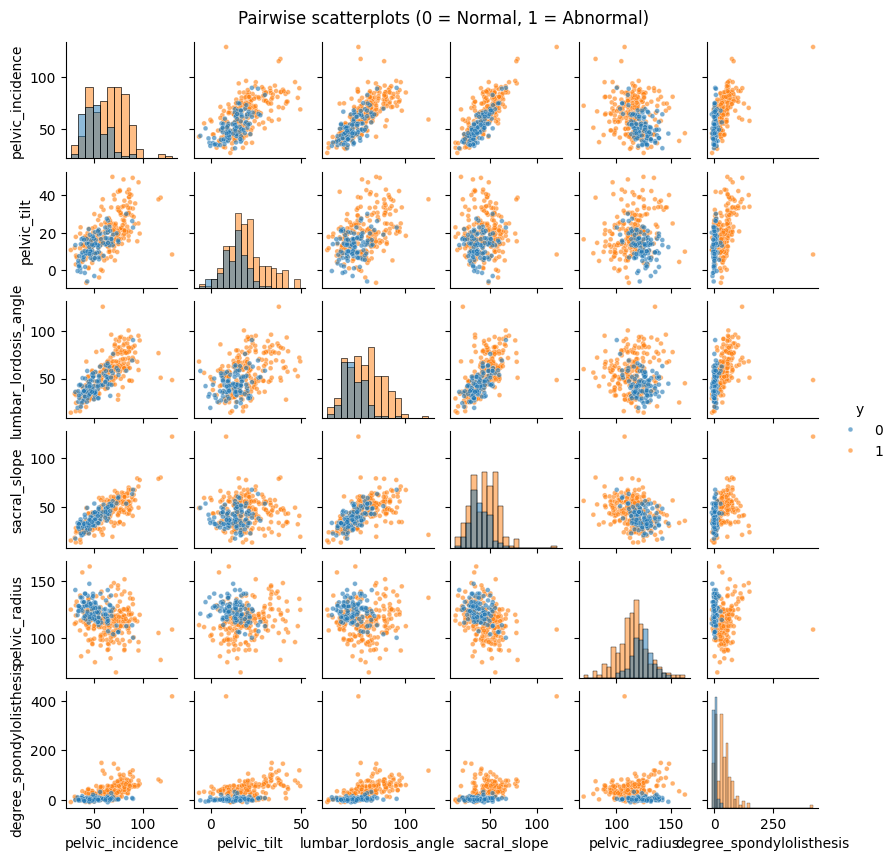

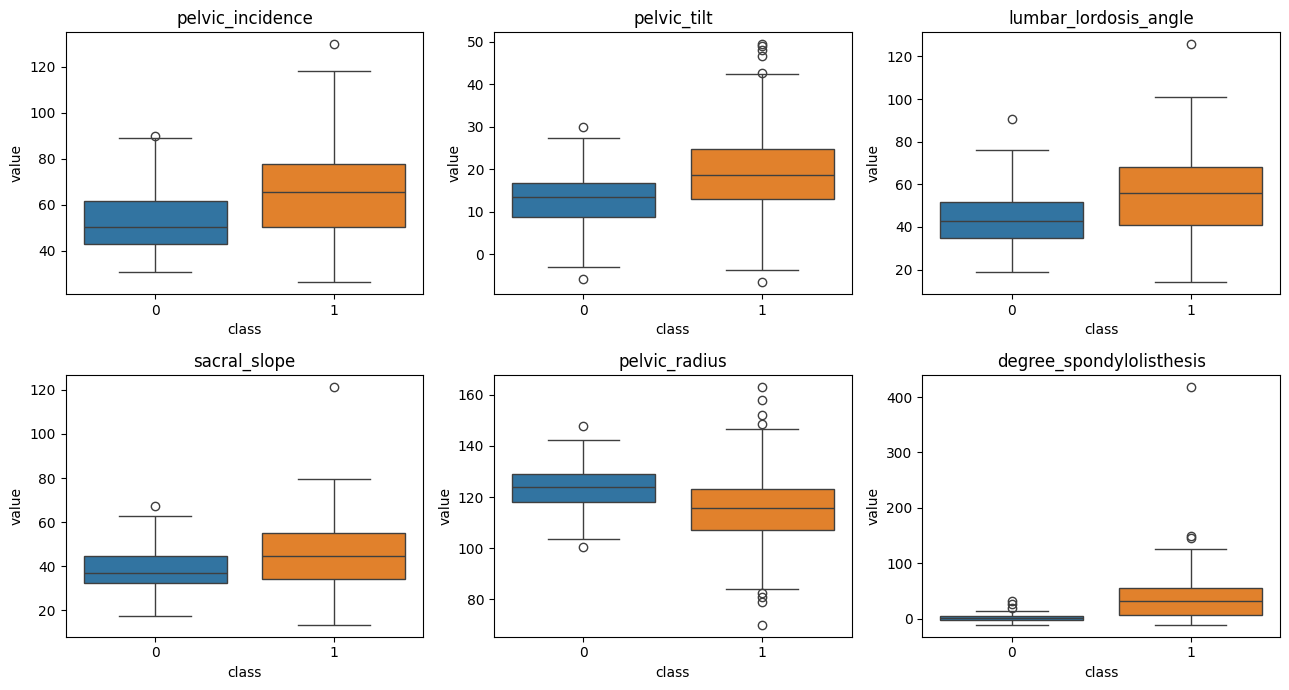

train: 210  test: 100
k* = 4   test error = 0.0600


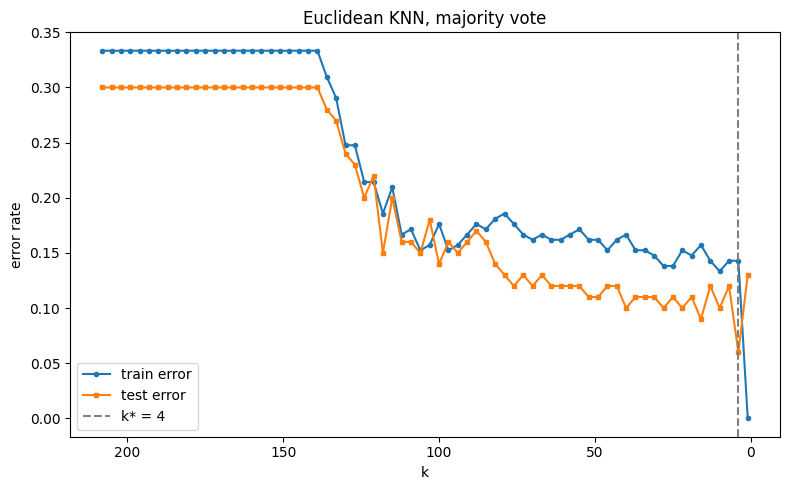


--- metrics at k* ---
Confusion matrix [[TP FN],[FP TN]] =
 [[69  1]
 [ 5 25]]
TPR=0.986  TNR=0.833  precision=0.932  F1=0.958


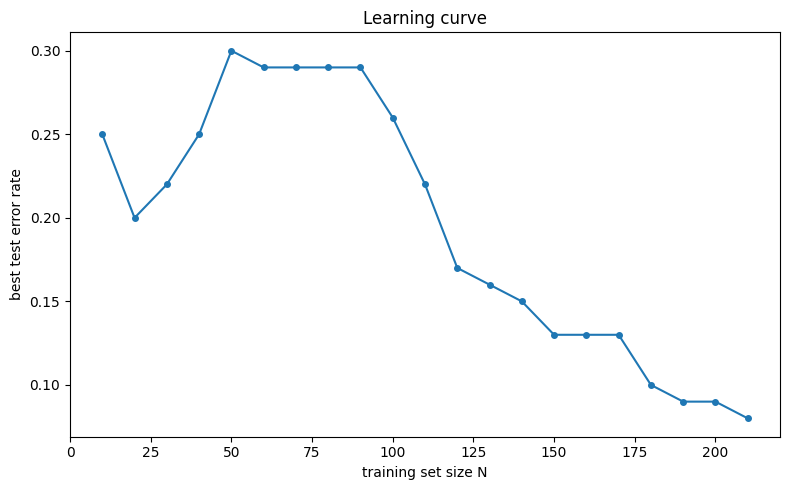

(d)iB best log10(p) = 0.7  (p=5.01)  err=0.1100

(d) summary of test errors:
                metric  best_k  test_error
             Chebyshev      16        0.08
             Euclidean       6        0.08
Minkowski log10(p)=0.7       1        0.11
       Manhattan (p=1)       1        0.11
           Mahalanobis       1        0.15

(e) distance-weighted voting, best test errors:
   metric  best_k  test_error
Euclidean       6        0.10
Manhattan      26        0.10
Chebyshev      16        0.11

(f) lowest training error rate = 0.0000  (achieved at k = 1)


In [ ]:
"""
EE 559 - Homework 1, Problem 7
Vertebral Column Data Set - KNN classification

Binary task:  NO (Normal) = 0,  AB (Abnormal) = 1   (positive class = AB = 1)

Changed: uses column_2C_weka.arff (higher precision) instead of column_2C.dat,
per instructor's note.
"""

# %% ---------------------------------------------------------------- imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from google.colab import drive
drive.mount('/content/drive')

import zipfile, glob
zip_path = '/content/drive/MyDrive/USC_Summer26/EE559/Data/vertebral_column_data.zip'
with zipfile.ZipFile(zip_path) as z:
    z.extractall('/content/vertebral')
    print(z.namelist())

# ---- CHANGED: .arff instead of .dat ----
DATA_PATH = glob.glob('/content/vertebral/**/column_2C_weka.arff', recursive=True)[0]
print('using:', DATA_PATH)


# %% ----------------------------------------------------- (a) load the data
def load_data(path=DATA_PATH):
    """Read column_2C_weka.arff (higher precision than .dat)."""
    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)
    # scipy arff returns bytes for nominal attributes -> decode
    for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
    # The class column is the last one (named 'class' in the Weka arff)
    class_col = meta.names()[-1]            # typically 'class'
    df['y'] = (df[class_col].str.upper().str[:2] == 'AB').astype(int)
    df = df.drop(columns=[class_col])       # drop original string class column
    return df


df = load_data()
COLS = [c for c in df.columns if c != 'y']  # all feature columns (auto-detected)
print(df['y'].value_counts())               # expect 1->210, 0->100


# %% --------------------------------------- (b) i. scatterplots, coloured by class
def scatter_matrix_by_class(df):
    g = sns.pairplot(df, vars=COLS, hue="y", diag_kind="hist",
                     plot_kws={"s": 12, "alpha": 0.6}, height=1.4)
    g.figure.suptitle("Pairwise scatterplots (0 = Normal, 1 = Abnormal)", y=1.02)
    plt.savefig("b_i_scatterplots.png", dpi=150, bbox_inches="tight")
    plt.show()

scatter_matrix_by_class(df)


# %% --------------------------------------- (b) ii. boxplots, coloured by class
def boxplots_by_class(df):
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    long = df.melt(id_vars="y", value_vars=COLS,
                   var_name="feature", value_name="value")
    for ax, feat in zip(axes.ravel(), COLS):
        sns.boxplot(data=long[long.feature == feat], x="y", y="value",
                    hue="y", ax=ax, legend=False)
        ax.set_title(feat); ax.set_xlabel("class")
    fig.tight_layout()
    plt.savefig("b_ii_boxplots.png", dpi=150, bbox_inches="tight")
    plt.show()

boxplots_by_class(df)


# %% -------------------------------------------- (b) iii. train / test split
def make_split(df, n0=70, n1=140):
    """First n0 rows of class 0 and first n1 rows of class 1 -> train; rest -> test."""
    df0, df1 = df[df.y == 0], df[df.y == 1]
    train = pd.concat([df0.iloc[:n0], df1.iloc[:n1]])
    test  = pd.concat([df0.iloc[n0:], df1.iloc[n1:]])
    Xtr, ytr = train[COLS].to_numpy(), train["y"].to_numpy()
    Xte, yte = test[COLS].to_numpy(),  test["y"].to_numpy()
    return Xtr, ytr, Xte, yte


Xtr, ytr, Xte, yte = make_split(df)
print(f"train: {Xtr.shape[0]}  test: {Xte.shape[0]}")  # 210 / 100


# %% --------------------------------- helper: fit KNN and return error rates
def knn_errors(Xtr, ytr, Xte, yte, k, **kw):
    """Return (train_error, test_error) for a KNN with the given settings."""
    k = min(k, len(Xtr))
    clf = KNeighborsClassifier(n_neighbors=k, **kw).fit(Xtr, ytr)
    tr_err = np.mean(clf.predict(Xtr) != ytr)
    te_err = np.mean(clf.predict(Xte) != yte)
    return tr_err, te_err


# %% ---------------------- (c) ii. error vs k, Euclidean, majority vote
k_values = list(range(1, 209, 3))              # {1, 4, 7, ..., 208}
train_err, test_err = [], []
for k in k_values:
    tr, te = knn_errors(Xtr, ytr, Xte, yte, k, metric="euclidean", weights="uniform")
    train_err.append(tr); test_err.append(te)

k_star = k_values[int(np.argmin(test_err))]
print(f"k* = {k_star}   test error = {min(test_err):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_err, "o-", ms=3, label="train error")
plt.plot(k_values, test_err,  "s-", ms=3, label="test error")
plt.axvline(k_star, ls="--", c="grey", label=f"k* = {k_star}")
plt.gca().invert_xaxis()
plt.xlabel("k"); plt.ylabel("error rate"); plt.legend()
plt.title("Euclidean KNN, majority vote"); plt.tight_layout()
plt.savefig("c_ii_error_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()


# %% --------------- (c) ii. confusion matrix & metrics at k* (positive = AB = 1)
def report_metrics(Xtr, ytr, Xte, yte, k, **kw):
    clf = KNeighborsClassifier(n_neighbors=k, **kw).fit(Xtr, ytr)
    yhat = clf.predict(Xte)
    cm = confusion_matrix(yte, yhat, labels=[1, 0])   # rows/cols ordered [pos, neg]
    tp, fn, fp, tn = cm.ravel()
    tpr  = tp / (tp + fn)
    tnr  = tn / (tn + fp)
    prec = tp / (tp + fp)
    f1   = 2 * prec * tpr / (prec + tpr)
    print("Confusion matrix [[TP FN],[FP TN]] =\n", np.array([[tp, fn], [fp, tn]]))
    print(f"TPR={tpr:.3f}  TNR={tnr:.3f}  precision={prec:.3f}  F1={f1:.3f}")
    return dict(TP=tp, FN=fn, FP=fp, TN=tn, TPR=tpr, TNR=tnr, precision=prec, F1=f1)

print("\n--- metrics at k* ---")
report_metrics(Xtr, ytr, Xte, yte, k_star, metric="euclidean", weights="uniform")


# %% --------------------------------------- (c) iii. learning curve
def best_test_error_for_N(df, N):
    """Build the size-N training subset, sweep k in {1,6,...}, return min test error."""
    n0 = N // 3
    n1 = N - n0
    df0, df1 = df[df.y == 0], df[df.y == 1]
    sub = pd.concat([df0.iloc[:n0], df1.iloc[:n1]])
    Xs, ys = sub[COLS].to_numpy(), sub["y"].to_numpy()
    ks = [k for k in range(1, N, 5) if k <= len(Xs)]
    errs = [knn_errors(Xs, ys, Xte, yte, k, metric="euclidean")[1] for k in ks]
    return min(errs)

N_values = list(range(10, 211, 10))
lc = [best_test_error_for_N(df, N) for N in N_values]

plt.figure(figsize=(8, 5))
plt.plot(N_values, lc, "o-", ms=4)
plt.xlabel("training set size N"); plt.ylabel("best test error rate")
plt.title("Learning curve"); plt.tight_layout()
plt.savefig("c_iii_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()


# %% --------------------------------------- (d) other distance metrics
ks_d = list(range(1, 197, 5))

def best_k(Xtr, ytr, Xte, yte, ks, **kw):
    errs = [knn_errors(Xtr, ytr, Xte, yte, k, **kw)[1] for k in ks]
    j = int(np.argmin(errs))
    return ks[j], errs[j]

results = {}

# (d) i.A  Manhattan  (Minkowski p = 1)
k_manh, err_manh = best_k(Xtr, ytr, Xte, yte, ks_d, metric="minkowski", p=1)
results["Manhattan (p=1)"] = (k_manh, err_manh)

# (d) i.B  Minkowski with log10(p) in {0.1,...,1.0}, reuse k* from Manhattan
log10p = np.arange(0.1, 1.0001, 0.1)
mink_errs = [(lp, knn_errors(Xtr, ytr, Xte, yte, k_manh,
                             metric="minkowski", p=10**lp)[1]) for lp in log10p]
best_lp, best_lp_err = min(mink_errs, key=lambda t: t[1])
print(f"(d)iB best log10(p) = {best_lp:.1f}  (p={10**best_lp:.2f})  err={best_lp_err:.4f}")
results[f"Minkowski log10(p)={best_lp:.1f}"] = (k_manh, best_lp_err)

# (d) i.C  Chebyshev  (Minkowski p -> inf)
k_cheb, err_cheb = best_k(Xtr, ytr, Xte, yte, ks_d, metric="chebyshev")
results["Chebyshev"] = (k_cheb, err_cheb)

# (d) ii.  Mahalanobis (pseudoinverse handles singular covariance)
VI = np.linalg.pinv(np.cov(Xtr, rowvar=False))
k_mah, err_mah = best_k(Xtr, ytr, Xte, yte, ks_d,
                        metric="mahalanobis", metric_params={"VI": VI},
                        algorithm="brute")
results["Mahalanobis"] = (k_mah, err_mah)

# also Euclidean on the same grid for the summary table
k_euc, err_euc = best_k(Xtr, ytr, Xte, yte, ks_d, metric="euclidean")
results["Euclidean"] = (k_euc, err_euc)

summary_d = pd.DataFrame(
    [(name, k, e) for name, (k, e) in results.items()],
    columns=["metric", "best_k", "test_error"]).sort_values("test_error")
print("\n(d) summary of test errors:")
print(summary_d.to_string(index=False))


# %% --------------------------------------- (e) distance-weighted voting
ks_e = list(range(1, 197, 5))
weighted = {}
for name, kw in [("Euclidean", dict(metric="euclidean")),
                 ("Manhattan", dict(metric="minkowski", p=1)),
                 ("Chebyshev", dict(metric="chebyshev"))]:
    k_best, e_best = best_k(Xtr, ytr, Xte, yte, ks_e, weights="distance", **kw)
    weighted[name] = (k_best, e_best)

summary_e = pd.DataFrame(
    [(name, k, e) for name, (k, e) in weighted.items()],
    columns=["metric", "best_k", "test_error"]).sort_values("test_error")
print("\n(e) distance-weighted voting, best test errors:")
print(summary_e.to_string(index=False))


# %% --------------------------------------- (f) lowest TRAINING error
tr1, _ = knn_errors(Xtr, ytr, Xtr, ytr, 1, metric="euclidean")
print(f"\n(f) lowest training error rate = {tr1:.4f}  (achieved at k = 1)")